# 04 — PYMK EDA: 1-hop, 2-hop và candidate generation

Notebook này xây dựng baseline People You May Know bằng graph undirected: lấy vùng 2-hop, loại target và 1-hop neighbors, sau đó tính Common Neighbors, Jaccard và Adamic-Adar để quan sát candidate. Đây là EDA, chưa phải mô hình production.

In [1]:
# Nhập thư viện cho sparse graph, score và trực quan hóa PYMK.
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy import sparse

In [2]:
# Nạp graph, tạo undirected adjacency và hàm lấy neighbors.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "MGTAB"

def load_tensor(name):
    try:
        return torch.load(DATA_DIR / name, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(DATA_DIR / name, map_location="cpu")

edge_index = load_tensor("edge_index.pt").long()
labels_bot = load_tensor("labels_bot.pt").long().numpy()
src = edge_index[0].numpy()
dst = edge_index[1].numpy()
num_nodes = int(labels_bot.shape[0])

# PYMK baseline dùng một adjacency undirected, loại duplicate edge.
row = np.concatenate([src, dst])
col = np.concatenate([dst, src])
adj = sparse.csr_matrix((np.ones(len(row), dtype=np.int8), (row, col)), shape=(num_nodes, num_nodes))
adj.data[:] = 1
adj.eliminate_zeros()

def neighbors(node):
    return adj.indices[adj.indptr[node]:adj.indptr[node + 1]]

degree = np.diff(adj.indptr)
print(f"nodes={num_nodes:,}, undirected edges={adj.nnz // 2:,}")

nodes=10,199, undirected edges=905,658


## 1. Chọn target và kiểm tra 1-hop / 2-hop

In [3]:
# Định nghĩa candidate PYMK bằng 2-hop sau khi loại target và 1-hop.
def generate_candidates(target):
    if not 0 <= target < num_nodes:
        raise ValueError(f"target phải nằm trong [0, {num_nodes - 1}]")
    one_hop = neighbors(target)
    if len(one_hop) == 0:
        return one_hop, np.array([], dtype=np.int64), np.array([], dtype=np.int64)
    two_hop_pool = np.unique(np.concatenate([neighbors(node) for node in one_hop]))
    candidate_mask = ~np.isin(two_hop_pool, np.concatenate(([target], one_hop)))
    candidates = two_hop_pool[candidate_mask]
    return one_hop, two_hop_pool, candidates

# Có thể thay TARGET_NODE bằng user ID muốn khảo sát.
TARGET_NODE = int(np.argmax(degree))
one_hop, two_hop_pool, candidates = generate_candidates(TARGET_NODE)
print("Target node:", TARGET_NODE)
print("Target degree / 1-hop count:", len(one_hop))
print("2-hop pool size:", len(two_hop_pool))
print("Final candidate count:", len(candidates))

Target node: 3632
Target degree / 1-hop count: 5009
2-hop pool size: 10113
Final candidate count: 5104


In [4]:
# Tính Common Neighbors, Jaccard và Adamic-Adar cho candidate.
def score_candidates(target, candidate_nodes):
    target_neighbors = neighbors(target)
    target_degree = max(len(target_neighbors), 1)
    rows = []
    for candidate in candidate_nodes:
        candidate_neighbors = neighbors(int(candidate))
        common = np.intersect1d(target_neighbors, candidate_neighbors, assume_unique=True)
        cn = len(common)
        union_size = len(np.union1d(target_neighbors, candidate_neighbors))
        jaccard = cn / union_size if union_size else 0.0
        aa = float(np.sum(1.0 / np.log(np.maximum(degree[common], 2)))) if cn else 0.0
        rows.append({
            "target": target,
            "candidate": int(candidate),
            "common_neighbors": cn,
            "jaccard": jaccard,
            "adamic_adar": aa,
            "candidate_degree": int(degree[candidate]),
            "bot_label": int(labels_bot[candidate]),
        })
    return pd.DataFrame(rows)

candidate_scores = score_candidates(TARGET_NODE, candidates)
candidate_scores.sort_values(["common_neighbors", "adamic_adar"], ascending=False).head(20)

,target,candidate,common_neighbors,jaccard,adamic_adar,candidate_degree,bot_label
2720,3632,5417,2303,0.400591,487.619073,3043,0
3840,3632,7700,1566,0.280645,348.268706,2137,0
1768,3632,3487,1554,0.276463,279.860214,2166,0
1477,3632,2893,1379,0.245592,257.412559,1985,0
782,3632,1494,1316,0.241379,234.630736,1759,0
2188,3632,4335,1128,0.207544,205.261164,1554,0
2349,3632,4670,1039,0.175863,185.355718,1938,0
4419,3632,8867,939,0.177572,162.373465,1218,0
2774,3632,5534,900,0.168602,168.635116,1229,0
3369,3632,6720,882,0.166102,157.352401,1183,0


## 2. Phân phối candidate và structural scores

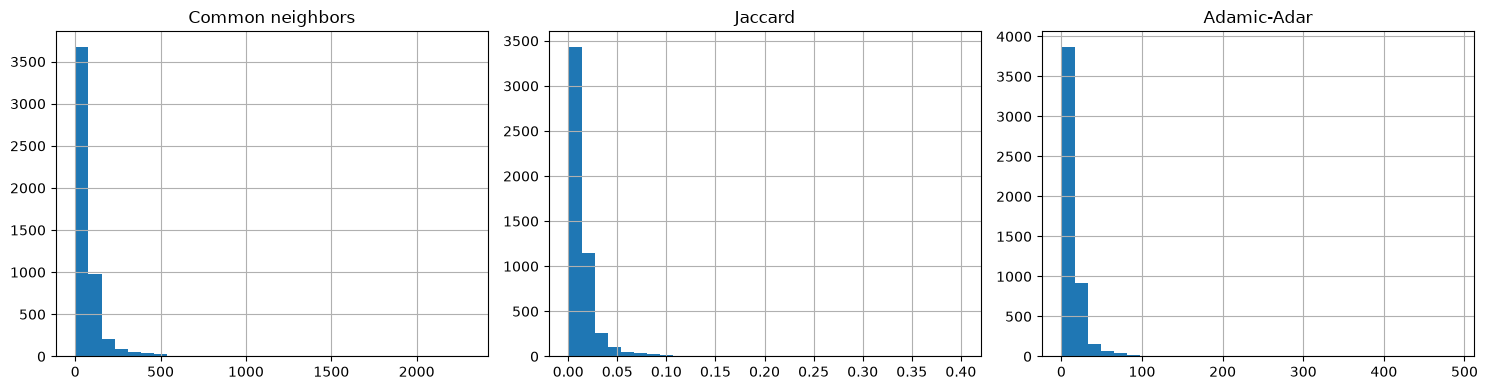

In [5]:
# Vẽ phân phối các structural score của candidate.
if not candidate_scores.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    candidate_scores["common_neighbors"].hist(ax=axes[0], bins=30)
    candidate_scores["jaccard"].hist(ax=axes[1], bins=30)
    candidate_scores["adamic_adar"].hist(ax=axes[2], bins=30)
    axes[0].set_title("Common neighbors")
    axes[1].set_title("Jaccard")
    axes[2].set_title("Adamic-Adar")
    plt.tight_layout()
    plt.show()
else:
    print("Target không có 2-hop candidate.")

In [ ]:
# Khảo sát candidate count trên nhóm target có degree cao.
# Khảo sát nhiều target đại diện theo degree, không tính toàn bộ user.
target_count = min(20, num_nodes)
sample_targets = np.argsort(degree)[-target_count:][::-1]
rows = []
for target in sample_targets:
    one, pool, cand = generate_candidates(int(target))
    rows.append({
        "target": int(target),
        "degree": int(len(one)),
        "two_hop_pool": int(len(pool)),
        "candidate_count": int(len(cand)),
        "bot_label": int(labels_bot[target]),
    })

multi_target_report = pd.DataFrame(rows)
multi_target_report

,target,degree,two_hop_pool,candidate_count,bot_label
0,3632,5009,10113,5104,0
1,5417,3043,10067,7024,0
2,5241,2824,10073,7249,0
3,1914,2682,10056,7374,0
4,2180,2585,10032,7447,0
5,8296,2566,10046,7480,0
6,311,2364,10079,7715,0
7,960,2238,10050,7812,0
8,3487,2166,9963,7797,0
9,7700,2137,9995,7858,0


In [ ]:
# Tính phân phối candidate count trên toàn bộ node.
all_node_rows = []
for i, target in enumerate(range(num_nodes), start=1):
    one, _, cand = generate_candidates(target)
    all_node_rows.append({
        "target": target,
        "degree": len(one),
        "candidate_count": len(cand),
    })
    if i % 1000 == 0:
        print(f"processed {i:,}/{num_nodes:,} nodes")

all_node_candidates = pd.DataFrame(all_node_rows)
candidate_distribution = pd.DataFrame({
    "metric": ["mean", "median", "p90", "p95", "max", "no_candidate_share", "with_candidate_share"],
    "value": [
        all_node_candidates["candidate_count"].mean(),
        all_node_candidates["candidate_count"].median(),
        all_node_candidates["candidate_count"].quantile(0.90),
        all_node_candidates["candidate_count"].quantile(0.95),
        all_node_candidates["candidate_count"].max(),
        (all_node_candidates["candidate_count"] == 0).mean(),
        (all_node_candidates["candidate_count"] > 0).mean(),
    ],
})
display(candidate_distribution)
all_node_candidates.plot.scatter(x="degree", y="candidate_count", alpha=0.2, figsize=(6, 4), title="Degree vs candidate count")
plt.show()

## 3. Kết luận EDA

- 1-hop là các connection hiện tại và phải loại khỏi recommendation.
- 2-hop candidate là heuristic để giảm không gian tìm kiếm, không phải bằng chứng chắc chắn của connection tương lai.
- Common Neighbors, Jaccard và Adamic-Adar tạo ra các ranking khác nhau; bước tiếp theo có thể so sánh chúng bằng train/validation/test edge split.
- Candidate generation chưa dùng label bot để lọc; label chỉ được hiển thị để hiểu rủi ro nếu hệ thống recommendation cần tránh tài khoản bot.